# 03 — Walk-forward model benchmark

This notebook visualizes the validation leaderboard and the locked-test comparison. The final test period is not used to select models. Run `make train` first if the processed reports are missing.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'data').exists(): ROOT = (ROOT / '..').resolve()
processed = ROOT / 'data/processed'
gold_leaderboard = pd.read_csv(processed / 'gold_leaderboard.csv')
silver_leaderboard = pd.read_csv(processed / 'silver_leaderboard.csv')
gold_test = pd.read_csv(processed / 'gold_test_comparison.csv')
silver_test = pd.read_csv(processed / 'silver_test_comparison.csv')
display(gold_leaderboard)
display(silver_leaderboard)

,family,best_score,best_params,eligible_final_model
0,zero,0.000000,{},False
1,extra_trees,0.618012,"{'max_depth': 6, 'max_features': 0.7, 'min_sam...",True
2,tree_blend,0.618012,{'extra_trees_weight': 1.0},True
3,xgboost,0.497191,"{'learning_rate': 0.03, 'max_depth': 2, 'n_est...",True
4,elasticnet,0.380784,"{'model__alpha': 0.001, 'model__l1_ratio': 0.9}",True
5,hist_gradient_boosting,0.346412,"{'l2_regularization': 0.0, 'learning_rate': 0....",True
6,ridge,0.097359,{'model__alpha': 0.1},True
7,directional_logistic,-0.265913,"{'C': 0.3, 'class_weight': 'balanced', 'predic...",True
8,moving_average,-0.341549,{},True
9,patch_tst,-1.290538,"{'dropout': 0.1, 'epochs': 5, 'hidden_dim': 16...",True


,family,best_score,best_params,eligible_final_model
0,zero,0.000000,{},False
1,directional_logistic,1.451147,"{'C': 0.3, 'class_weight': 'balanced', 'predic...",True
2,xgboost,0.615446,"{'learning_rate': 0.03, 'max_depth': 4, 'n_est...",True
3,hist_gradient_boosting,0.490226,"{'l2_regularization': 1.0, 'learning_rate': 0....",True
4,elasticnet,0.486478,"{'model__alpha': 0.001, 'model__l1_ratio': 0.5}",True
5,ridge,0.406363,{'model__alpha': 100.0},True
6,tree_blend,0.382038,{'extra_trees_weight': 0.5},True
7,patch_tst,0.254543,"{'dropout': 0.1, 'epochs': 5, 'hidden_dim': 16...",True
8,moving_average,-0.107651,{},True
9,extra_trees,-0.112084,"{'max_depth': 4, 'max_features': 1.0, 'min_sam...",True


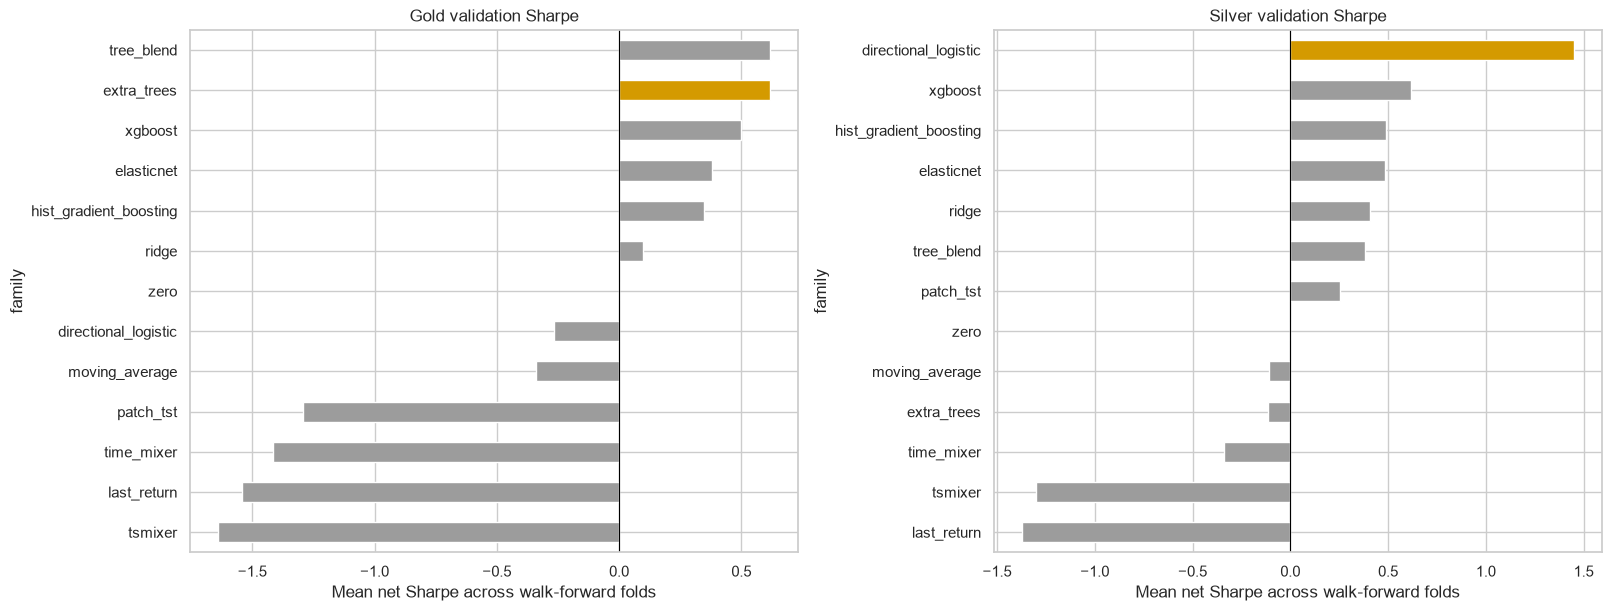

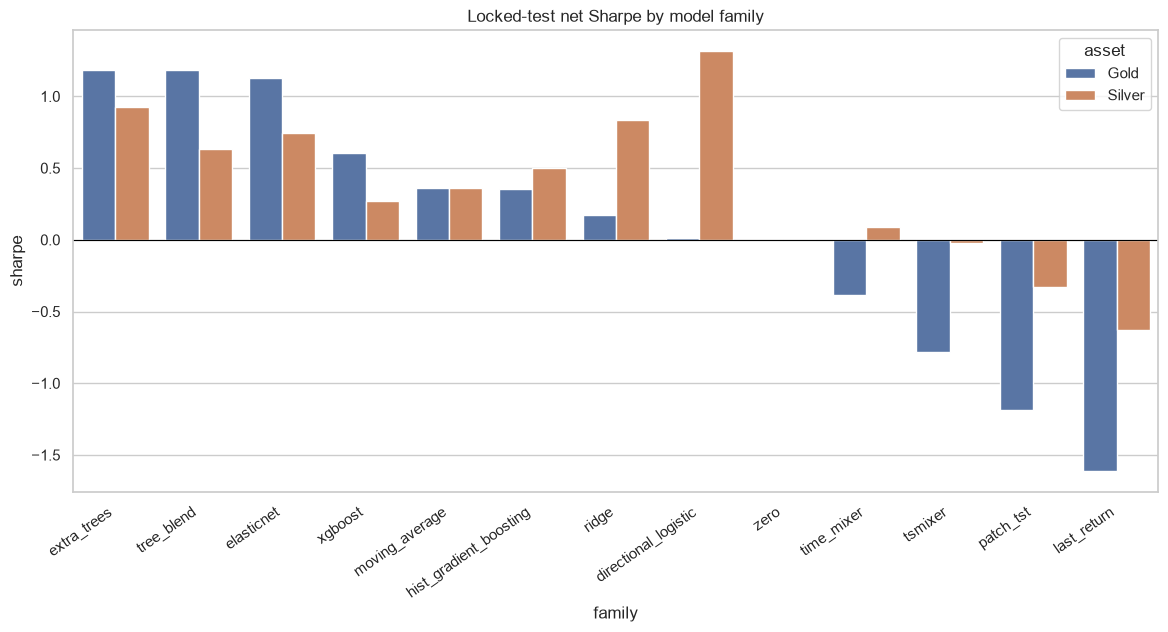

In [2]:
sns.set_theme(style='whitegrid', context='notebook')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
selected_family = {'Gold': gold_test.loc[gold_test['selected'], 'family'].iloc[0], 'Silver': silver_test.loc[silver_test['selected'], 'family'].iloc[0]}
for table, asset, ax in [(gold_leaderboard, 'Gold', axes[0]), (silver_leaderboard, 'Silver', axes[1])]:
    ordered = table.sort_values('best_score')
    colors = ['#d49a00' if x else '#9c9c9c' for x in ordered['family'].eq(selected_family[asset])]
    ordered.plot.barh(x='family', y='best_score', ax=ax, legend=False, color=colors, title=f'{asset} validation Sharpe')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean net Sharpe across walk-forward folds')
plt.show()

test_plot = pd.concat([gold_test.assign(asset='Gold'), silver_test.assign(asset='Silver')])
plt.figure(figsize=(14, 6))
sns.barplot(data=test_plot, x='family', y='sharpe', hue='asset')
plt.xticks(rotation=35, ha='right')
plt.title('Locked-test net Sharpe by model family')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

**How to read the plots.** Validation Sharpe is the average net risk-adjusted return across chronological folds; it is the selection signal. The locked-test bars are a one-time out-of-sample check, so a model that wins there after selection is encouraging but not proof of SOTA.